<a href="https://colab.research.google.com/github/SharuNivetha06/RNN_LSTM_GRU/blob/main/RNN_LSTM_GRU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os, time, zipfile, io, urllib.request, math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                              confusion_matrix, classification_report)
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 4)

TensorFlow: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
HAR_ZIP_PATH = "drive/MyDrive/UCI HAR Dataset.zip"

DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

with zipfile.ZipFile(HAR_ZIP_PATH, "r") as z:
    z.extractall(DATA_DIR)

HAR_DIR = os.path.join(DATA_DIR, "UCI HAR Dataset")
assert os.path.isdir(os.path.join(HAR_DIR, "train", "Inertial Signals")), \
    f"Couldn't find train/Inertial Signals under {HAR_DIR} — check the zip's internal folder name."

print("Using HAR_DIR =", HAR_DIR)

Using HAR_DIR = data/UCI HAR Dataset


In [3]:
SIGNALS = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z",
]

ACTIVITY_NAMES = {
    1: "WALKING", 2: "WALKING_UPSTAIRS", 3: "WALKING_DOWNSTAIRS",
    4: "SITTING", 5: "STANDING", 6: "LAYING",
}

def load_signals(split):
    """Load raw inertial signals for a split ('train' or 'test') -> (N, 128, 9)."""
    base = os.path.join(HAR_DIR, split, "Inertial Signals")
    channels = []
    for sig in SIGNALS:
        fname = os.path.join(base, f"{sig}_{split}.txt")
        arr = np.loadtxt(fname)
        channels.append(arr)
    X = np.stack(channels, axis=-1)
    return X

def load_labels(split):
    fname = os.path.join(HAR_DIR, split, f"y_{split}.txt")
    y = np.loadtxt(fname).astype(int)
    return y - 1

X_train_full = load_signals("train")
y_train_full = load_labels("train")
X_test_full  = load_signals("test")
y_test_full  = load_labels("test")

print("Full train:", X_train_full.shape, "Full test:", X_test_full.shape)

Full train: (7352, 128, 9) Full test: (2947, 128, 9)


In [4]:
N_SUBSET = 3000

def balanced_subset(X, y, n_total, seed=SEED):
    rng = np.random.RandomState(seed)
    classes = np.unique(y)
    per_class = n_total // len(classes)
    idxs = []
    for c in classes:
        c_idx = np.where(y == c)[0]
        rng.shuffle(c_idx)
        idxs.append(c_idx[:per_class])
    idxs = np.concatenate(idxs)
    rng.shuffle(idxs)
    return X[idxs], y[idxs]

X_sub, y_sub = balanced_subset(X_train_full, y_train_full, N_SUBSET)
print("Subset shape:", X_sub.shape)
print("Class distribution:", np.bincount(y_sub))

Subset shape: (3000, 128, 9)
Class distribution: [500 500 500 500 500 500]


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_sub, y_sub, test_size=0.15/0.85, stratify=y_sub, random_state=SEED
)

X_test, _, y_test, _ = train_test_split(
    X_test_full, y_test_full, train_size=0.4, stratify=y_test_full, random_state=SEED
)

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

Train: (2470, 128, 9) Val: (530, 128, 9) Test: (1178, 128, 9)


In [6]:
n_features = X_train.shape[-1]
mean = X_train.reshape(-1, n_features).mean(axis=0)
std  = X_train.reshape(-1, n_features).std(axis=0) + 1e-8

def normalize(X):
    return (X - mean) / std

X_train_n = normalize(X_train)
X_val_n   = normalize(X_val)
X_test_n  = normalize(X_test)

N_train, T, F = X_train_n.shape
N_val = X_val_n.shape[0]
N_test = X_test_n.shape[0]
N_CLASSES = 6

print("Input tensor shape:")
print(f"  Training   : {X_train_n.shape}")
print(f"  Validation : {X_val_n.shape}")
print(f"  Testing    : {X_test_n.shape}")
print(f"Number of classes: {N_CLASSES}")
print(f"Number of features per time step: {F}")
print(f"Sequence length: {T}")

Input tensor shape:
  Training   : (2470, 128, 9)
  Validation : (530, 128, 9)
  Testing    : (1178, 128, 9)
Number of classes: 6
Number of features per time step: 9
Sequence length: 128


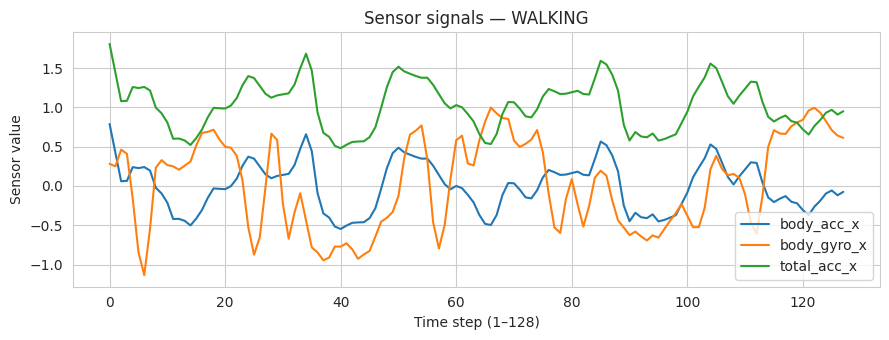

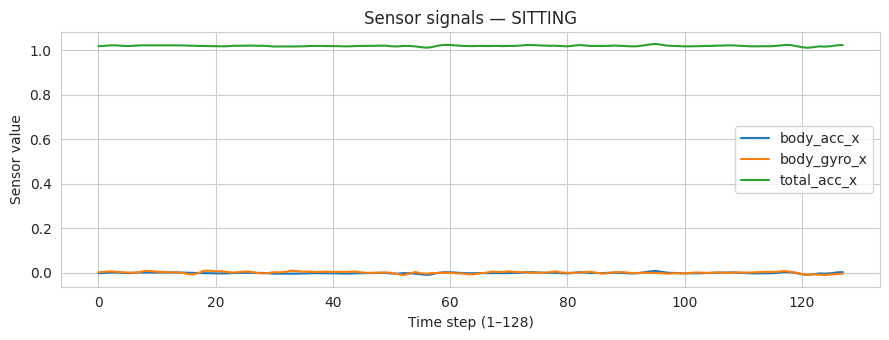

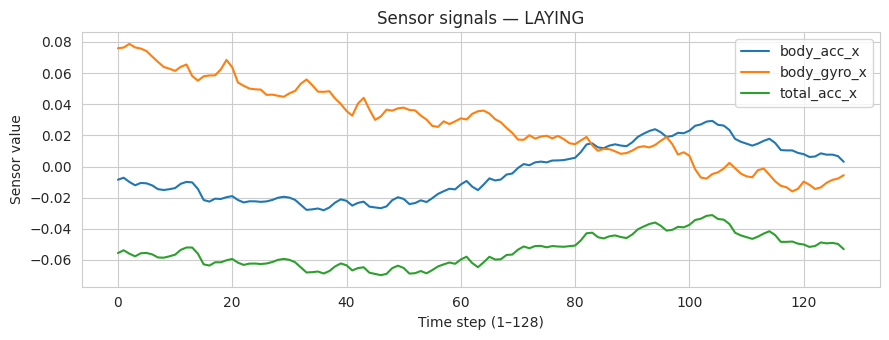

In [7]:
def plot_sequence_for_class(X, y, class_id, channels=(0, 3, 6), channel_names=None):
    idx = np.where(y == class_id)[0][0]
    seq = X[idx]
    if channel_names is None:
        channel_names = [SIGNALS[c] for c in channels]
    plt.figure(figsize=(9, 3.5))
    for c, name in zip(channels, channel_names):
        plt.plot(seq[:, c], label=name)
    plt.title(f"Sensor signals — {ACTIVITY_NAMES[class_id + 1]}")
    plt.xlabel("Time step (1–128)")
    plt.ylabel("Sensor value")
    plt.legend()
    plt.tight_layout()
    plt.show()

for cid in [0, 3, 5]:
    plot_sequence_for_class(X_train, y_train, cid)

In [8]:
x = [0.5, 0.7, 0.2]
h = 0.0
Wx, Wh, b = 0.5, 0.8, 0.1

hs = []
for t, xt in enumerate(x, start=1):
    h = math.tanh(Wx * xt + Wh * h + b)
    hs.append(h)
    print(f"h{t} = tanh({Wx}*{xt} + {Wh}*{'0' if t==1 else 'h'+str(t-1)} + {b}) = {h:.6f}")

print("\nCompare with a program (identical formula, verifies manual work):", [round(v,6) for v in hs])

h1 = tanh(0.5*0.5 + 0.8*0 + 0.1) = 0.336376
h2 = tanh(0.5*0.7 + 0.8*h1 + 0.1) = 0.616352
h3 = tanh(0.5*0.2 + 0.8*h2 + 0.1) = 0.599958

Compare with a program (identical formula, verifies manual work): [0.336376, 0.616352, 0.599958]


In [9]:
RECURRENT_UNITS = 32
DROPOUT = 0.2
LR = 1e-3
BATCH_SIZE = 32
EPOCHS = 30

def build_model(recurrent_type, units=RECURRENT_UNITS, input_shape=(T, F), n_classes=N_CLASSES):
    if recurrent_type == "RNN":
        rec_layer = layers.SimpleRNN(units)
    elif recurrent_type == "LSTM":
        rec_layer = layers.LSTM(units)
    elif recurrent_type == "GRU":
        rec_layer = layers.GRU(units)
    else:
        raise ValueError(recurrent_type)

    model = models.Sequential([
        layers.Input(shape=input_shape),
        rec_layer,
        layers.Dropout(DROPOUT),
        layers.Dense(16, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ], name=f"{recurrent_type}_classifier")

    model.compile(
        optimizer=optimizers.Adam(learning_rate=LR),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

def train_and_time(model, X_tr, y_tr, X_va, y_va, epochs=EPOCHS, verbose=0):
    es = callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
    t0 = time.time()
    history = model.fit(
        X_tr, y_tr, validation_data=(X_va, y_va),
        epochs=epochs, batch_size=BATCH_SIZE, callbacks=[es], verbose=verbose
    )
    train_time = time.time() - t0
    return history, train_time

def evaluate_model(model, X_te, y_te):
    y_prob = model.predict(X_te, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)
    acc = accuracy_score(y_te, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_te, y_pred, average="macro", zero_division=0)
    cm = confusion_matrix(y_te, y_pred)
    n_params = model.count_params()
    return {
        "accuracy": acc, "precision": prec, "recall": rec, "f1": f1,
        "params": n_params, "y_pred": y_pred, "cm": cm,
    }

def plot_history(history, title):
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    axes[0].plot(history.history["loss"], label="train loss")
    axes[0].plot(history.history["val_loss"], label="val loss")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
    axes[0].set_title(f"{title} — Loss")

    axes[1].plot(np.array(history.history["accuracy"]) * 100, label="train acc")
    axes[1].plot(np.array(history.history["val_accuracy"]) * 100, label="val acc")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)"); axes[1].legend()
    axes[1].set_title(f"{title} — Accuracy")
    plt.tight_layout(); plt.show()

def plot_confusion(cm, title):
    plt.figure(figsize=(5.5, 4.5))
    labels = [ACTIVITY_NAMES[i+1] for i in range(N_CLASSES)]
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title(f"Confusion Matrix — {title}")
    plt.xticks(rotation=45, ha="right"); plt.tight_layout(); plt.show()

In [10]:
results = {}
histories = {}

for rtype in ["RNN", "LSTM", "GRU"]:
    print(f"\n=== Training {rtype} ===")
    model = build_model(rtype)
    hist, ttime = train_and_time(model, X_train_n, y_train, X_val_n, y_val, verbose=0)
    metrics = evaluate_model(model, X_test_n, y_test)
    metrics["train_time"] = ttime
    metrics["model"] = model
    results[rtype] = metrics
    histories[rtype] = hist
    print(f"{rtype}: acc={metrics['accuracy']:.4f} f1={metrics['f1']:.4f} "
          f"params={metrics['params']} time={ttime:.1f}s")


=== Training RNN ===
RNN: acc=0.7793 f1=0.7742 params=1974 time=32.4s

=== Training LSTM ===
LSTM: acc=0.8922 f1=0.8911 params=6006 time=29.6s

=== Training GRU ===
GRU: acc=0.8846 f1=0.8836 params=4758 time=25.6s


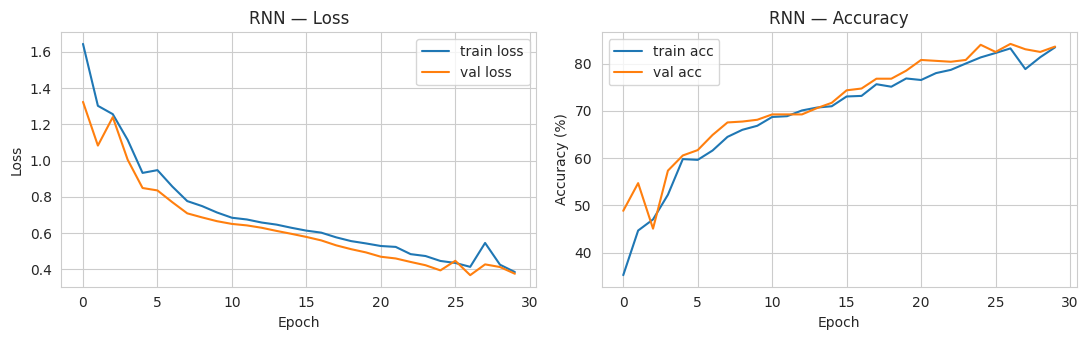

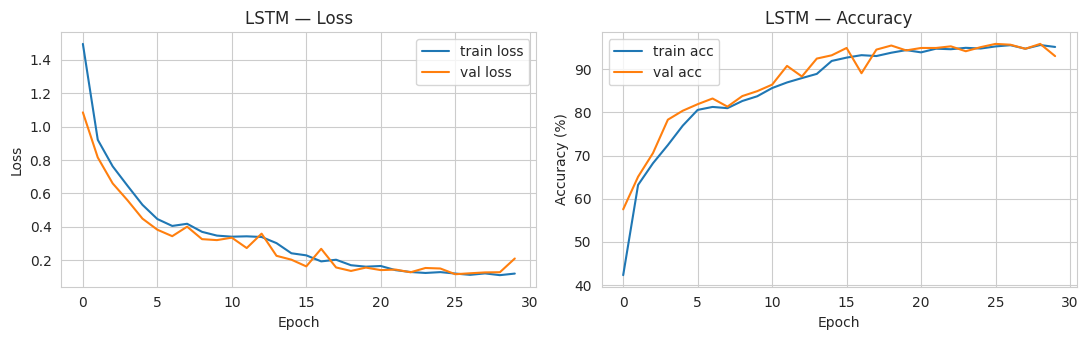

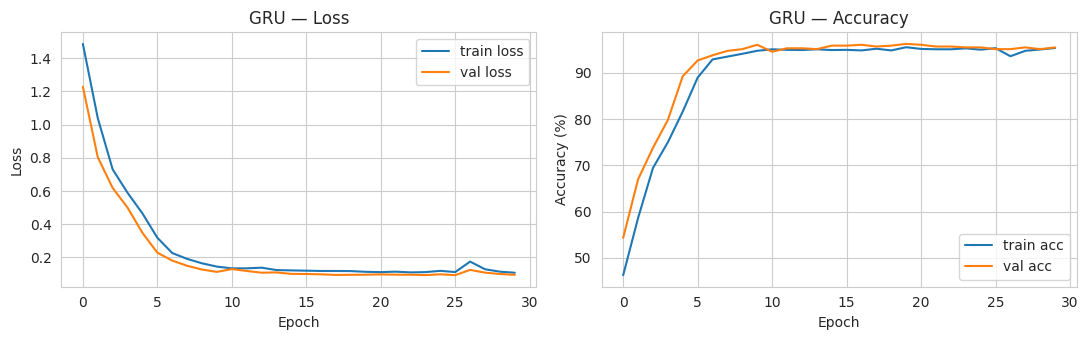

In [11]:
for rtype in ["RNN", "LSTM", "GRU"]:
    plot_history(histories[rtype], rtype)

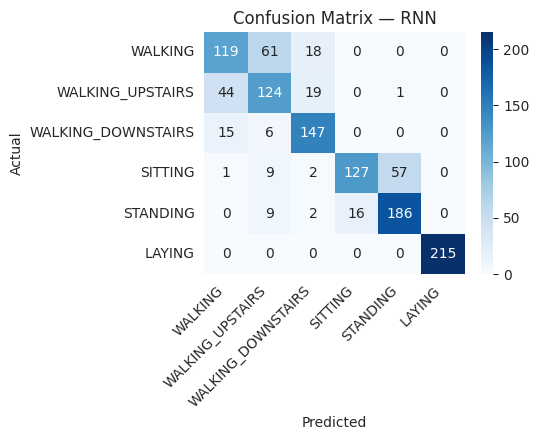

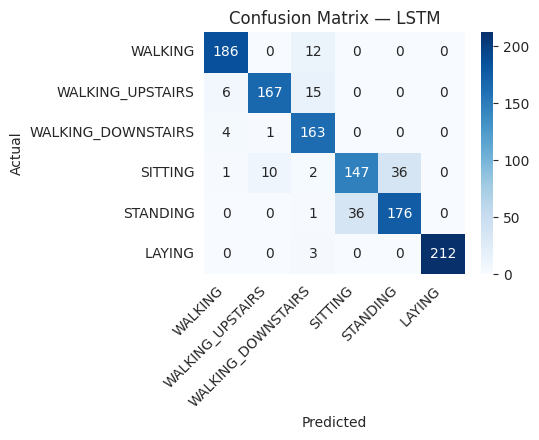

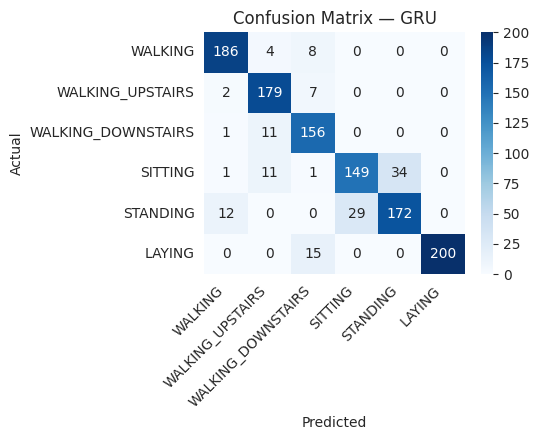

In [12]:
for rtype in ["RNN", "LSTM", "GRU"]:
    plot_confusion(results[rtype]["cm"], rtype)

In [13]:
comparison_df = pd.DataFrame({
    rtype: {
        "Accuracy (%)": results[rtype]["accuracy"] * 100,
        "Macro Precision (%)": results[rtype]["precision"] * 100,
        "Macro Recall (%)": results[rtype]["recall"] * 100,
        "Macro F1 (%)": results[rtype]["f1"] * 100,
        "Parameters": results[rtype]["params"],
        "Training Time (s)": results[rtype]["train_time"],
    }
    for rtype in ["RNN", "LSTM", "GRU"]
}).T
comparison_df

,Accuracy (%),Macro Precision (%),Macro Recall (%),Macro F1 (%),Parameters,Training Time (s)
RNN,77.928693,78.173796,77.613053,77.418241,1974.0,32.433386
LSTM,89.219015,89.124412,89.337792,89.114666,6006.0,29.593601
GRU,88.455008,88.336959,88.634023,88.357733,4758.0,25.636941


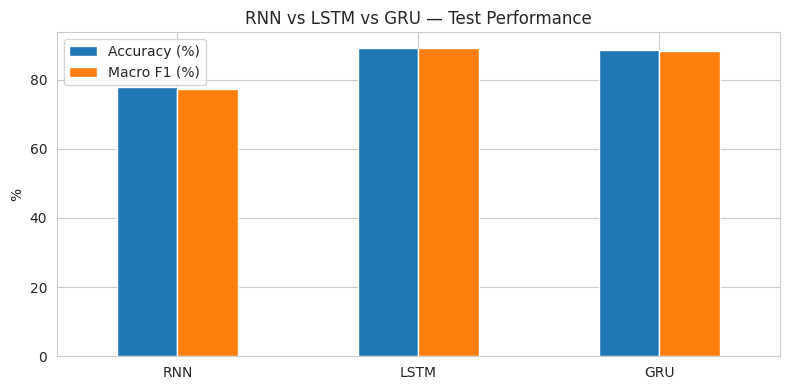

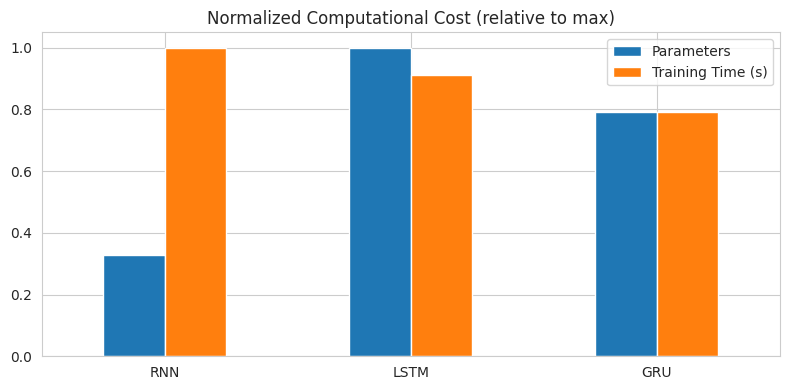

In [14]:
fig, ax = plt.subplots(figsize=(8, 4))
metrics_to_plot = ["Accuracy (%)", "Macro F1 (%)"]
comparison_df[metrics_to_plot].plot(kind="bar", ax=ax)
ax.set_title("RNN vs LSTM vs GRU — Test Performance")
ax.set_ylabel("%")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
norm_cost = comparison_df[["Parameters", "Training Time (s)"]] / comparison_df[["Parameters", "Training Time (s)"]].max()
norm_cost.plot(kind="bar", ax=ax)
ax.set_title("Normalized Computational Cost (relative to max)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [15]:
def truncate_sequences(X, length):
    """Take the first `length` time steps of each 128-step window."""
    return X[:, :length, :]

seq_lengths = [32, 64, 128]
seqlen_results = {rtype: {} for rtype in ["RNN", "LSTM", "GRU"]}

for L in seq_lengths:
    X_tr_L = truncate_sequences(X_train_n, L)
    X_va_L = truncate_sequences(X_val_n, L)
    X_te_L = truncate_sequences(X_test_n, L)
    for rtype in ["RNN", "LSTM", "GRU"]:
        model = build_model(rtype, input_shape=(L, F))
        hist, ttime = train_and_time(model, X_tr_L, y_train, X_va_L, y_val, epochs=EPOCHS, verbose=0)
        m = evaluate_model(model, X_te_L, y_test)
        seqlen_results[rtype][L] = m["f1"]
        print(f"T={L:3d} {rtype}: F1={m['f1']:.4f}")

seqlen_df = pd.DataFrame(seqlen_results)
seqlen_df.index.name = "Sequence Length"
seqlen_df

T= 32 RNN: F1=0.7719
T= 32 LSTM: F1=0.8611
T= 32 GRU: F1=0.8736
T= 64 RNN: F1=0.7677
T= 64 LSTM: F1=0.8883
T= 64 GRU: F1=0.8768
T=128 RNN: F1=0.7760
T=128 LSTM: F1=0.8841
T=128 GRU: F1=0.8976


,RNN,LSTM,GRU
Sequence Length,,,
32,0.771926,0.861079,0.873556
64,0.767729,0.888346,0.876769
128,0.775984,0.884144,0.897597


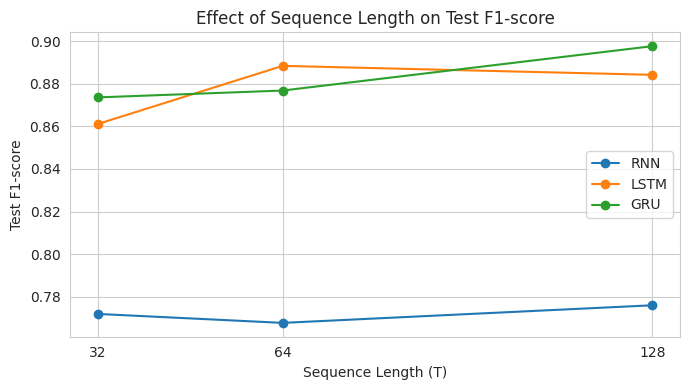

In [16]:
plt.figure(figsize=(7, 4))
for rtype in ["RNN", "LSTM", "GRU"]:
    plt.plot(seq_lengths, [seqlen_results[rtype][L] for L in seq_lengths], marker="o", label=rtype)
plt.xlabel("Sequence Length (T)")
plt.ylabel("Test F1-score")
plt.title("Effect of Sequence Length on Test F1-score")
plt.xticks(seq_lengths)
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
UCF101_URL = "https://www.crcv.ucf.edu/data/UCF101/UCF101.rar"
VIDEO_CLASSES = ["Basketball", "Biking", "WalkingWithDog", "JumpingJack", "TennisSwing"]
VIDEOS_PER_CLASS = 8
FRAMES_PER_VIDEO = 10
FRAME_SIZE = (224, 224)

VIDEO_DIR = os.path.join(DATA_DIR, "UCF101_subset")
os.makedirs(VIDEO_DIR, exist_ok=True)

print("Expected folder layout:")
for c in VIDEO_CLASSES:
    print(f"  {VIDEO_DIR}/{c}/*.avi")

Expected folder layout:
  data/UCF101_subset/Basketball/*.avi
  data/UCF101_subset/Biking/*.avi
  data/UCF101_subset/WalkingWithDog/*.avi
  data/UCF101_subset/JumpingJack/*.avi
  data/UCF101_subset/TennisSwing/*.avi


In [20]:
!pip install -q remotezip tqdm

import remotezip
from tqdm import tqdm

UCF_ZIP_URL = "https://huggingface.co/datasets/quchenyuan/UCF101-ZIP/resolve/main/UCF-101.zip"

with remotezip.RemoteZip(UCF_ZIP_URL) as zf:
    all_files = zf.namelist()
    print("Sample entries:", all_files[:5])

    for cname in VIDEO_CLASSES:
        matches = [f for f in all_files if f"/{cname}/" in f and f.lower().endswith(".avi")]
        random.seed(42)
        random.shuffle(matches)
        chosen = matches[:VIDEOS_PER_CLASS]

        cdir = os.path.join(VIDEO_DIR, cname)
        os.makedirs(cdir, exist_ok=True)
        print(f"{cname}: found {len(matches)} candidates, downloading {len(chosen)}")

        for f in tqdm(chosen):
            out_path = os.path.join(cdir, os.path.basename(f))
            if not os.path.exists(out_path):
                with zf.open(f) as src, open(out_path, "wb") as dst:
                    dst.write(src.read())

print("\nDone. Folder layout:")
for cname in VIDEO_CLASSES:
    cdir = os.path.join(VIDEO_DIR, cname)
    n = len(os.listdir(cdir)) if os.path.isdir(cdir) else 0
    print(f"  {cdir}: {n} videos")

Sample entries: ['UCF-101/', 'UCF-101/FrontCrawl/', 'UCF-101/FrontCrawl/v_FrontCrawl_g07_c07.avi', 'UCF-101/FrontCrawl/v_FrontCrawl_g20_c06.avi', 'UCF-101/FrontCrawl/v_FrontCrawl_g04_c02.avi']
Basketball: found 134 candidates, downloading 8


100%|██████████| 8/8 [00:03<00:00,  2.06it/s]


Biking: found 134 candidates, downloading 8


100%|██████████| 8/8 [00:04<00:00,  1.98it/s]


WalkingWithDog: found 123 candidates, downloading 8


...

JumpingJack: found 123 candidates, downloading 8


100%|██████████| 8/8 [00:03<00:00,  2.07it/s]


TennisSwing: found 166 candidates, downloading 8


100%|██████████| 8/8 [00:04<00:00,  1.91it/s]


Done. Folder layout:
  data/UCF101_subset/Basketball: 8 videos
  data/UCF101_subset/Biking: 8 videos
  data/UCF101_subset/WalkingWithDog: 8 videos
  data/UCF101_subset/JumpingJack: 8 videos
  data/UCF101_subset/TennisSwing: 8 videos


In [22]:
import cv2

def sample_frames(video_path, n_frames=FRAMES_PER_VIDEO, size=FRAME_SIZE):
    cap = cv2.VideoCapture(video_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total <= 0:
        cap.release()
        return None
    idxs = np.linspace(0, max(total - 1, 0), n_frames).astype(int)
    frames = []
    idx_set = set(idxs.tolist())
    i = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        if i in idx_set:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, size)
            frames.append(frame)
        i += 1
        if len(frames) == n_frames:
            break
    cap.release()
    if len(frames) < n_frames:
        return None
    return np.stack(frames, axis=0)

def collect_video_dataset(video_dir, classes, videos_per_class):
    paths, labels = [], []
    for ci, cname in enumerate(classes):
        cdir = os.path.join(video_dir, cname)
        if not os.path.isdir(cdir):
            print(f"WARNING: missing folder {cdir} — populate before running this cell.")
            continue
        files = sorted([f for f in os.listdir(cdir) if f.lower().endswith((".avi", ".mp4"))])[:videos_per_class]
        for f in files:
            paths.append(os.path.join(cdir, f))
            labels.append(ci)
    return paths, np.array(labels)

video_paths, video_labels = collect_video_dataset(VIDEO_DIR, VIDEO_CLASSES, VIDEOS_PER_CLASS)
print(f"Collected {len(video_paths)} videos across {len(VIDEO_CLASSES)} classes.")

Collected 40 videos across 5 classes.


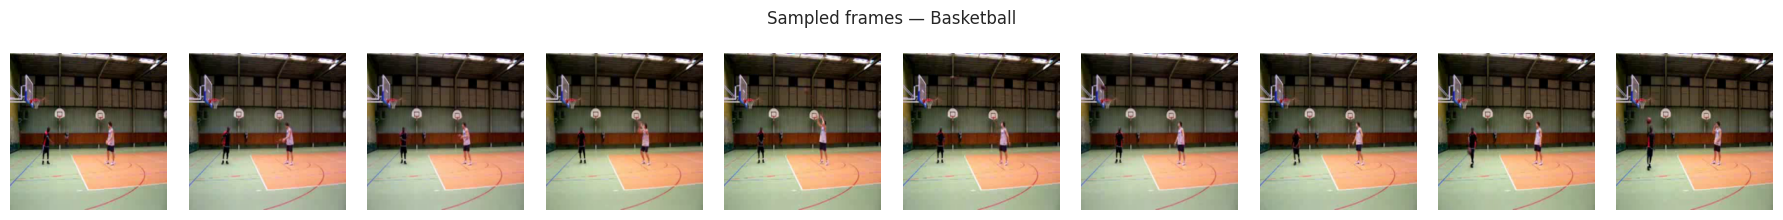

In [23]:
if len(video_paths) > 0:
    frames = sample_frames(video_paths[0])
    if frames is not None:
        fig, axes = plt.subplots(1, FRAMES_PER_VIDEO, figsize=(18, 2.2))
        for i, ax in enumerate(axes):
            ax.imshow(frames[i])
            ax.axis("off")
        fig.suptitle(f"Sampled frames — {VIDEO_CLASSES[video_labels[0]]}")
        plt.tight_layout()
        plt.show()
else:
    print("No videos found yet — see the folder-layout note above before running this section.")

In [24]:
cnn_base = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3), include_top=False, weights="imagenet", pooling="avg"
)
cnn_base.trainable = False
FEATURE_DIM = cnn_base.output_shape[-1]
print("CNN feature dimension D =", FEATURE_DIM)

preprocess = tf.keras.applications.mobilenet_v2.preprocess_input

def extract_video_features(paths, labels):
    feats, keep_labels = [], []
    for p, lab in zip(paths, labels):
        frames = sample_frames(p)
        if frames is None:
            continue
        x = preprocess(frames.astype(np.float32))
        f = cnn_base.predict(x, verbose=0)       # (10, D)
        feats.append(f)
        keep_labels.append(lab)
    if not feats:
        return np.zeros((0, FRAMES_PER_VIDEO, FEATURE_DIM)), np.zeros((0,), dtype=int)
    return np.stack(feats, axis=0), np.array(keep_labels)

X_vid, y_vid = extract_video_features(video_paths, video_labels)
print("Video feature tensor shape supplied to the recurrent network:", X_vid.shape)  # (B, 10, D)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
CNN feature dimension D = 1280
Video feature tensor shape supplied to the recurrent network: (36, 10, 1280)


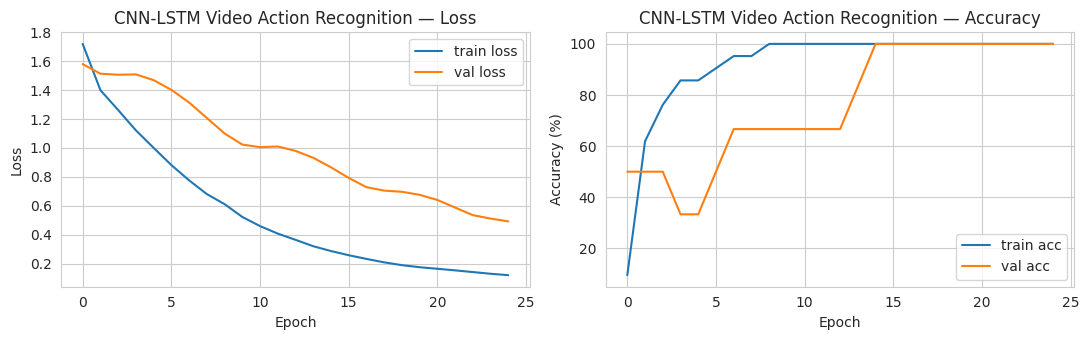

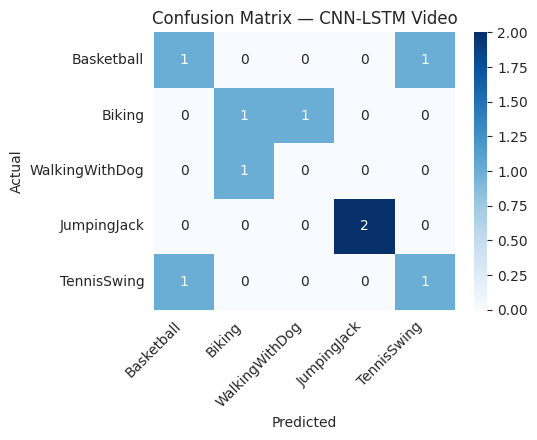

Video model — acc=0.5556  f1=0.5000

Predicted class : TennisSwing
Actual class    : TennisSwing
Confidence      : 0.74


In [49]:
if len(X_vid) >= 10:
    Xv_tr, Xv_te, yv_tr, yv_te = train_test_split(
        X_vid, y_vid, test_size=0.25, stratify=y_vid, random_state=SEED
    )
    Xv_tr, Xv_va, yv_tr, yv_va = train_test_split(
        Xv_tr, yv_tr, test_size=0.2, stratify=yv_tr, random_state=SEED
    )

    def build_video_model(recurrent_type="LSTM", units=32, n_classes=len(VIDEO_CLASSES)):
        rec = layers.LSTM(units) if recurrent_type == "LSTM" else layers.GRU(units)
        model = models.Sequential([
            layers.Input(shape=(FRAMES_PER_VIDEO, FEATURE_DIM)),
            rec,
            layers.Dense(16, activation="relu"),
            layers.Dense(n_classes, activation="softmax"),
        ])
        model.compile(optimizer=optimizers.Adam(1e-3),
                       loss="sparse_categorical_crossentropy", metrics=["accuracy"])
        return model

    video_model = build_video_model("LSTM")
    vid_hist, vid_time = train_and_time(video_model, Xv_tr, yv_tr, Xv_va, yv_va, epochs=25, verbose=0)
    plot_history(vid_hist, "CNN-LSTM Video Action Recognition")

    vid_metrics = evaluate_model(video_model, Xv_te, yv_te)

    plt.figure(figsize=(5.5, 4.5))
    sns.heatmap(vid_metrics["cm"], annot=True, fmt="d", cmap="Blues",
                xticklabels=VIDEO_CLASSES, yticklabels=VIDEO_CLASSES)
    plt.xlabel("Predicted"); plt.ylabel("Actual")
    plt.title("Confusion Matrix — CNN-LSTM Video")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

    print(f"Video model — acc={vid_metrics['accuracy']:.4f}  f1={vid_metrics['f1']:.4f}")

    probs = video_model.predict(Xv_te[:1], verbose=0)[0]
    pred_idx = int(np.argmax(probs))
    print(f"\nPredicted class : {VIDEO_CLASSES[pred_idx]}")
    print(f"Actual class    : {VIDEO_CLASSES[yv_te[0]]}")
    print(f"Confidence      : {probs[pred_idx]:.2f}")
else:
    print("Skipping training — populate the UCF101 subset folders described above first.")

In [26]:
SEQ_LEN = 6
VOCAB_MIN, VOCAB_MAX = 1, 9
N_SAMPLES = 20000
START_TOKEN = 0
VOCAB_SIZE = VOCAB_MAX + 1

def generate_reversal_dataset(n_samples, seq_len, seed=SEED):
    rng = np.random.RandomState(seed)
    X = rng.randint(VOCAB_MIN, VOCAB_MAX + 1, size=(n_samples, seq_len))
    Y = X[:, ::-1]
    return X, Y

X_seq, Y_seq = generate_reversal_dataset(N_SAMPLES, SEQ_LEN)
print("Example:", X_seq[0], "->", Y_seq[0])

Xs_tr, Xs_tmp, Ys_tr, Ys_tmp = train_test_split(X_seq, Y_seq, test_size=0.3, random_state=SEED)
Xs_va, Xs_te, Ys_va, Ys_te = train_test_split(Xs_tmp, Ys_tmp, test_size=0.5, random_state=SEED)
print("Train/Val/Test:", Xs_tr.shape, Xs_va.shape, Xs_te.shape)

Example: [7 4 8 5 7 3] -> [3 7 5 8 4 7]
Train/Val/Test: (14000, 6) (3000, 6) (3000, 6)


In [28]:
def make_decoder_input(Y):
    dec_in = np.zeros_like(Y)
    dec_in[:, 0] = START_TOKEN
    dec_in[:, 1:] = Y[:, :-1]
    return dec_in

Ys_tr_in, Ys_va_in, Ys_te_in = map(make_decoder_input, [Ys_tr, Ys_va, Ys_te])

EMBED_DIM = 32
LATENT_DIM = 64

# --- Encoder ---
enc_inputs = layers.Input(shape=(SEQ_LEN,), name="encoder_input")
enc_emb = layers.Embedding(VOCAB_SIZE, EMBED_DIM)(enc_inputs)
_, state_h, state_c = layers.LSTM(LATENT_DIM, return_state=True)(enc_emb)
encoder_states = [state_h, state_c]

# --- Decoder ---
dec_inputs = layers.Input(shape=(SEQ_LEN,), name="decoder_input")
dec_emb_layer = layers.Embedding(VOCAB_SIZE, EMBED_DIM)
dec_emb = dec_emb_layer(dec_inputs)
dec_lstm = layers.LSTM(LATENT_DIM, return_sequences=True, return_state=True)
dec_outputs, _, _ = dec_lstm(dec_emb, initial_state=encoder_states)
dec_dense = layers.Dense(VOCAB_SIZE, activation="softmax")
dec_outputs = dec_dense(dec_outputs)

seq2seq_model = models.Model([enc_inputs, dec_inputs], dec_outputs, name="seq2seq_reversal")
seq2seq_model.compile(optimizer=optimizers.Adam(1e-3),
                       loss="sparse_categorical_crossentropy", metrics=["accuracy"])
seq2seq_model.summary()

Model: "seq2seq_reversal"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_2         │ (None, 6, 32)     │        320 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_3         │ (None, 6, 32)     │        320 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_7 (LSTM)       │ [(None, 64),      │     24,832 │ embedding_2[0][0] │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_8 (LSTM)       │ [(None, 6, 64),   │     24,832 │ embedding_3[0][0… │
│                     │ (None, 64),       │            │ lstm_7[0][1],     │
│                     │ (None, 64)]       │            │ lstm_7[0][2]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 6, 10)     │        650 │ lstm_8[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 50,954 (199.04 KB)

 Trainable params: 50,954 (199.04 KB)

 Non-trainable params: 0 (0.00 B)

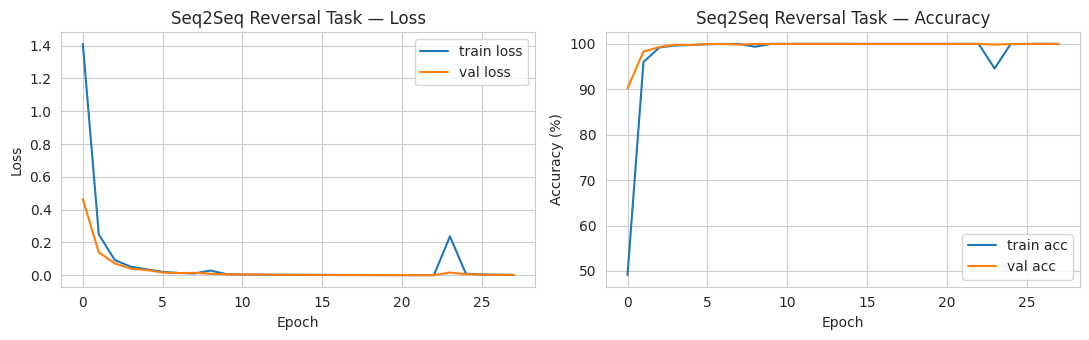

In [29]:
es = callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
seq2seq_hist = seq2seq_model.fit(
    [Xs_tr, Ys_tr_in], Ys_tr,
    validation_data=([Xs_va, Ys_va_in], Ys_va),
    epochs=30, batch_size=64, callbacks=[es], verbose=0,
)
plot_history(seq2seq_hist, "Seq2Seq Reversal Task")

In [32]:
encoder_model = models.Model(enc_inputs, encoder_states)

dec_state_h_in = layers.Input(shape=(LATENT_DIM,))
dec_state_c_in = layers.Input(shape=(LATENT_DIM,))
dec_single_input = layers.Input(shape=(1,))
dec_single_emb = dec_emb_layer(dec_single_input)
dec_single_out, dec_h, dec_c = dec_lstm(dec_single_emb, initial_state=[dec_state_h_in, dec_state_c_in])
dec_single_out = dec_dense(dec_single_out)
decoder_model = models.Model(
    [dec_single_input, dec_state_h_in, dec_state_c_in],
    [dec_single_out, dec_h, dec_c],
)

def predict_sequence(input_seq):
    states = encoder_model.predict(input_seq[None, :], verbose=0)
    target = np.array([[START_TOKEN]])
    output = []
    for _ in range(SEQ_LEN):
        probs, h, c = decoder_model.predict([target, states[0], states[1]], verbose=0)
        token = int(np.argmax(probs[0, -1, :]))
        output.append(token)
        target = np.array([[token]])
        states = [h, c]
    return np.array(output)

correct_tokens, total_tokens, correct_seqs = 0, 0, 0
sample_rows = []
for i in range(len(Xs_te)):
    pred = predict_sequence(Xs_te[i])
    correct_tokens += (pred == Ys_te[i]).sum()
    total_tokens += SEQ_LEN
    if np.array_equal(pred, Ys_te[i]):
        correct_seqs += 1
    if i < 5:
        sample_rows.append((Xs_te[i].tolist(), pred.tolist()))

token_acc = correct_tokens / total_tokens
seq_acc = correct_seqs / len(Xs_te)
print(f"Token accuracy    : {token_acc:.4f}")
print(f"Sequence accuracy : {seq_acc:.4f}")

print("\nSample Input Sequence -> Predicted Output")
for inp, pred in sample_rows:
    print(f"{inp} -> {pred}")

Token accuracy    : 0.9999
Sequence accuracy : 0.9993

Sample Input Sequence -> Predicted Output
[1, 5, 5, 1, 5, 7] -> [7, 5, 1, 5, 5, 1]
[7, 8, 3, 5, 1, 7] -> [7, 1, 5, 3, 8, 7]
[4, 1, 2, 2, 3, 2] -> [2, 3, 2, 2, 1, 4]
[8, 7, 9, 2, 6, 5] -> [5, 6, 2, 9, 7, 8]
[9, 3, 8, 2, 4, 7] -> [7, 4, 2, 8, 3, 9]


In [33]:
consolidated = comparison_df.copy()
consolidated = consolidated.rename(columns={
    "Accuracy (%)": "Accuracy", "Macro Precision (%)": "Precision",
    "Macro Recall (%)": "Recall", "Macro F1 (%)": "F1",
})[["Accuracy", "Precision", "Recall", "F1", "Parameters"]]

if len(X_vid) >= 10:
    consolidated.loc["CNN-LSTM/GRU (video)"] = [
        vid_metrics["accuracy"] * 100, vid_metrics["precision"] * 100,
        vid_metrics["recall"] * 100, vid_metrics["f1"] * 100, video_model.count_params(),
    ]

consolidated

,Accuracy,Precision,Recall,F1,Parameters
RNN,77.928693,78.173796,77.613053,77.418241,1974.0
LSTM,89.219015,89.124412,89.337792,89.114666,6006.0
GRU,88.455008,88.336959,88.634023,88.357733,4758.0
CNN-LSTM/GRU (video),55.555556,53.333333,60.000000,51.333333,168677.0


In [50]:
seq2seq_table = pd.DataFrame({
    "Token Accuracy": [token_acc],
    "Sequence Accuracy": [seq_acc],
    "Final Training Loss": [seq2seq_hist.history["loss"][-1]],
    "Final Validation Loss": [seq2seq_hist.history["val_loss"][-1]],
}, index=["Seq2Seq Reversal"])
seq2seq_table

,Token Accuracy,Sequence Accuracy,Final Training Loss,Final Validation Loss
Seq2Seq Reversal,0.999889,0.999333,0.002252,0.002353


In [35]:
unit_options = [16, 32, 64]
unit_sweep_rows = []

for rtype in ["RNN", "LSTM", "GRU"]:
    for units in unit_options:
        model = build_model(rtype, units=units)
        hist, ttime = train_and_time(model, X_train_n, y_train, X_val_n, y_val, epochs=EPOCHS, verbose=0)
        m = evaluate_model(model, X_test_n, y_test)
        unit_sweep_rows.append({
            "Model": rtype, "Units": units,
            "Accuracy (%)": m["accuracy"] * 100, "F1 (%)": m["f1"] * 100,
            "Parameters": m["params"], "Training Time (s)": ttime,
        })
        print(f"{rtype} units={units}: acc={m['accuracy']:.4f} f1={m['f1']:.4f} "
              f"params={m['params']} time={ttime:.1f}s")

unit_sweep_df = pd.DataFrame(unit_sweep_rows)
unit_sweep_df

RNN units=16: acc=0.6944 f1=0.6835 params=790 time=31.2s
RNN units=32: acc=0.7071 f1=0.6989 params=1974 time=32.0s
RNN units=64: acc=0.7012 f1=0.6915 params=5878 time=16.6s
LSTM units=16: acc=0.8905 f1=0.8897 params=2038 time=27.6s
LSTM units=32: acc=0.8854 f1=0.8849 params=6006 time=26.1s
LSTM units=64: acc=0.8947 f1=0.8949 params=20086 time=15.4s
GRU units=16: acc=0.8820 f1=0.8821 params=1670 time=25.9s
GRU units=32: acc=0.8922 f1=0.8915 params=4758 time=26.1s
GRU units=64: acc=0.9024 f1=0.9010 params=15542 time=22.0s


,Model,Units,Accuracy (%),F1 (%),Parameters,Training Time (s)
0,RNN,16,69.439728,68.351233,790,31.162183
1,RNN,32,70.713073,69.887804,1974,32.003099
2,RNN,64,70.118846,69.151404,5878,16.649506
3,LSTM,16,89.049236,88.969860,2038,27.607085
4,LSTM,32,88.539898,88.494198,6006,26.070083
5,LSTM,64,89.473684,89.493331,20086,15.377618
6,GRU,16,88.200340,88.207628,1670,25.914212
7,GRU,32,89.219015,89.150677,4758,26.077365
8,GRU,64,90.237691,90.095529,15542,22.015721


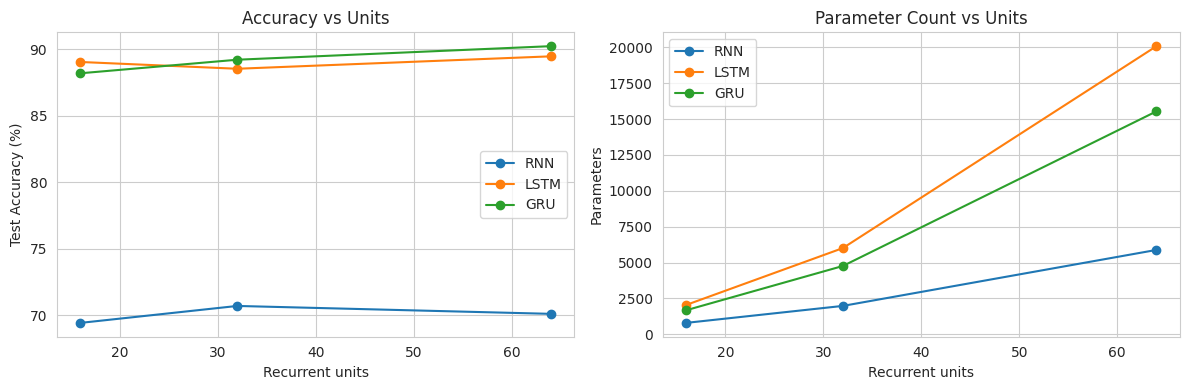

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for rtype in ["RNN", "LSTM", "GRU"]:
    sub = unit_sweep_df[unit_sweep_df["Model"] == rtype]
    axes[0].plot(sub["Units"], sub["Accuracy (%)"], marker="o", label=rtype)
    axes[1].plot(sub["Units"], sub["Parameters"], marker="o", label=rtype)
axes[0].set_xlabel("Recurrent units"); axes[0].set_ylabel("Test Accuracy (%)")
axes[0].set_title("Accuracy vs Units"); axes[0].legend()
axes[1].set_xlabel("Recurrent units"); axes[1].set_ylabel("Parameters")
axes[1].set_title("Parameter Count vs Units"); axes[1].legend()
plt.tight_layout(); plt.show()

In [37]:
gru_lstm_df = unit_sweep_df[unit_sweep_df["Model"].isin(["LSTM", "GRU"])].pivot(
    index="Units", columns="Model", values=["Accuracy (%)", "F1 (%)", "Parameters", "Training Time (s)"]
)
gru_lstm_df

Accuracy (%)                F1 (%)            Parameters           \
Model          GRU       LSTM        GRU       LSTM        GRU     LSTM   
Units                                                                     
16       88.200340  89.049236  88.207628  88.969860     1670.0   2038.0   
32       89.219015  88.539898  89.150677  88.494198     4758.0   6006.0   
64       90.237691  89.473684  90.095529  89.493331    15542.0  20086.0   

      Training Time (s)             
Model               GRU       LSTM  
Units                               
16            25.914212  27.607085  
32            26.077365  26.070083  
64            22.015721  15.377618

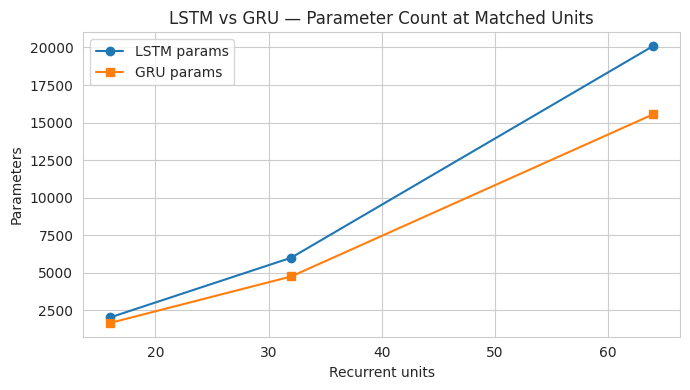

In [38]:
fig, ax = plt.subplots(figsize=(7, 4))
for rtype, marker in [("LSTM", "o"), ("GRU", "s")]:
    sub = unit_sweep_df[unit_sweep_df["Model"] == rtype]
    ax.plot(sub["Units"], sub["Parameters"], marker=marker, label=f"{rtype} params")
ax.set_xlabel("Recurrent units"); ax.set_ylabel("Parameters")
ax.set_title("LSTM vs GRU — Parameter Count at Matched Units")
ax.legend(); plt.tight_layout(); plt.show()

In [39]:
def build_stacked_model(recurrent_type, units=32, input_shape=(T, F), n_classes=N_CLASSES):
    Layer = {"RNN": layers.SimpleRNN, "LSTM": layers.LSTM, "GRU": layers.GRU}[recurrent_type]
    model = models.Sequential([
        layers.Input(shape=input_shape),
        Layer(units, return_sequences=True),
        layers.Dropout(DROPOUT),
        Layer(units),
        layers.Dropout(DROPOUT),
        layers.Dense(16, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ], name=f"{recurrent_type}_stacked")
    model.compile(optimizer=optimizers.Adam(LR),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

stacked_results = {}
for rtype in ["RNN", "LSTM", "GRU"]:
    model = build_stacked_model(rtype)
    hist, ttime = train_and_time(model, X_train_n, y_train, X_val_n, y_val, epochs=EPOCHS, verbose=0)
    m = evaluate_model(model, X_test_n, y_test)
    stacked_results[rtype] = {"accuracy": m["accuracy"], "f1": m["f1"],
                               "params": m["params"], "time": ttime}

stacked_vs_single = pd.DataFrame({
    "Single-layer Accuracy (%)": {r: results[r]["accuracy"]*100 for r in ["RNN","LSTM","GRU"]},
    "Stacked Accuracy (%)":      {r: stacked_results[r]["accuracy"]*100 for r in ["RNN","LSTM","GRU"]},
    "Single-layer F1 (%)":       {r: results[r]["f1"]*100 for r in ["RNN","LSTM","GRU"]},
    "Stacked F1 (%)":            {r: stacked_results[r]["f1"]*100 for r in ["RNN","LSTM","GRU"]},
    "Single-layer Params":       {r: results[r]["params"] for r in ["RNN","LSTM","GRU"]},
    "Stacked Params":            {r: stacked_results[r]["params"] for r in ["RNN","LSTM","GRU"]},
})
stacked_vs_single

,Single-layer Accuracy (%),Stacked Accuracy (%),Single-layer F1 (%),Stacked F1 (%),Single-layer Params,Stacked Params
RNN,77.928693,76.740238,77.418241,76.286181,1974,4054
LSTM,89.219015,89.728353,89.114666,89.681505,6006,14326
GRU,88.455008,88.370119,88.357733,88.415986,4758,11094


In [40]:
def build_bidirectional_model(units=32, input_shape=(T, F), n_classes=N_CLASSES):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        layers.Bidirectional(layers.LSTM(units)),
        layers.Dropout(DROPOUT),
        layers.Dense(16, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ], name="BiLSTM")
    model.compile(optimizer=optimizers.Adam(LR),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

bilstm_model = build_bidirectional_model()
bilstm_hist, bilstm_time = train_and_time(bilstm_model, X_train_n, y_train, X_val_n, y_val, epochs=EPOCHS, verbose=0)
bilstm_metrics = evaluate_model(bilstm_model, X_test_n, y_test)

bilstm_vs_uni = pd.DataFrame({
    "Unidirectional LSTM": {
        "Accuracy (%)": results["LSTM"]["accuracy"] * 100,
        "F1 (%)": results["LSTM"]["f1"] * 100,
        "Parameters": results["LSTM"]["params"],
        "Training Time (s)": results["LSTM"]["train_time"],
    },
    "Bidirectional LSTM": {
        "Accuracy (%)": bilstm_metrics["accuracy"] * 100,
        "F1 (%)": bilstm_metrics["f1"] * 100,
        "Parameters": bilstm_metrics["params"],
        "Training Time (s)": bilstm_time,
    },
}).T
bilstm_vs_uni

,Accuracy (%),F1 (%),Parameters,Training Time (s)
Unidirectional LSTM,89.219015,89.114666,6006.0,29.593601
Bidirectional LSTM,89.303905,89.391163,11894.0,40.882330


In [41]:
cost_by_length = []
for L in [32, 64, 128]:
    X_tr_L = truncate_sequences(X_train_n, L)
    X_va_L = truncate_sequences(X_val_n, L)
    for rtype in ["RNN", "LSTM", "GRU"]:
        model = build_model(rtype, input_shape=(L, F))
        _, ttime = train_and_time(model, X_tr_L, y_train, X_va_L, y_val, epochs=EPOCHS, verbose=0)
        cost_by_length.append({
            "Sequence Length": L, "Model": rtype,
            "Parameters": model.count_params(), "Training Time (s)": ttime,
        })

cost_df = pd.DataFrame(cost_by_length)
cost_df.pivot(index="Sequence Length", columns="Model", values="Training Time (s)")

Model,GRU,LSTM,RNN
Sequence Length,,,
32,13.336536,16.256609,20.713002
64,22.961472,23.174974,23.100945
128,25.854939,24.856203,30.946499


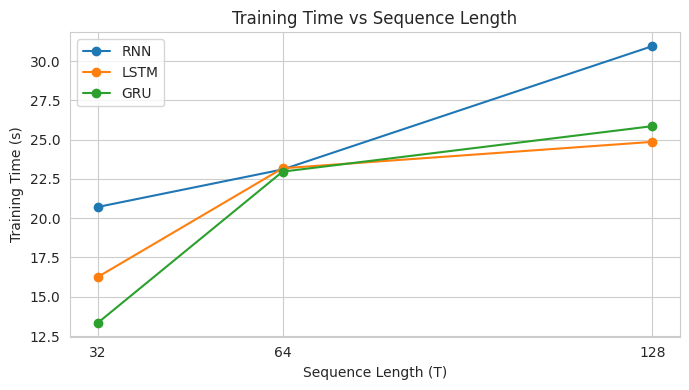

In [42]:
plt.figure(figsize=(7, 4))
for rtype in ["RNN", "LSTM", "GRU"]:
    sub = cost_df[cost_df["Model"] == rtype]
    plt.plot(sub["Sequence Length"], sub["Training Time (s)"], marker="o", label=rtype)
plt.xlabel("Sequence Length (T)"); plt.ylabel("Training Time (s)")
plt.title("Training Time vs Sequence Length")
plt.xticks([32, 64, 128]); plt.legend(); plt.tight_layout(); plt.show()

In [43]:
if len(X_vid) >= 10:
    video_compare = {}
    for rtype in ["LSTM", "GRU"]:
        vmodel = build_video_model(rtype)
        vhist, vtime = train_and_time(vmodel, Xv_tr, yv_tr, Xv_va, yv_va, epochs=25, verbose=0)
        vm = evaluate_model(vmodel, Xv_te, yv_te)
        video_compare[rtype] = {"accuracy": vm["accuracy"], "f1": vm["f1"],
                                 "params": vm["params"], "time": vtime}
        print(rtype, video_compare[rtype])

    pd.DataFrame(video_compare).T
else:
    print("Skipping — populate the UCF101 subset folders (Section 9) first.")

LSTM {'accuracy': 0.6666666666666666, 'f1': 0.49333333333333335, 'params': 168677, 'time': 3.708378314971924}
GRU {'accuracy': 0.6666666666666666, 'f1': 0.5666666666666667, 'params': 126757, 'time': 5.140566110610962}


In [44]:
IN_LEN = 6
OUT_LEN = 3

def generate_variable_length_dataset(n_samples, in_len, out_len, seed=SEED):
    rng = np.random.RandomState(seed)
    X = rng.randint(VOCAB_MIN, VOCAB_MAX + 1, size=(n_samples, in_len))
    Y = X[:, :out_len][:, ::-1]
    return X, Y

Xv2, Yv2 = generate_variable_length_dataset(N_SAMPLES, IN_LEN, OUT_LEN)
print("Example:", Xv2[0], "->", Yv2[0])

Xv2_tr, Xv2_tmp, Yv2_tr, Yv2_tmp = train_test_split(Xv2, Yv2, test_size=0.3, random_state=SEED)
Xv2_va, Xv2_te, Yv2_va, Yv2_te = train_test_split(Xv2_tmp, Yv2_tmp, test_size=0.5, random_state=SEED)

def make_decoder_input_v2(Y):
    dec_in = np.zeros_like(Y)
    dec_in[:, 0] = START_TOKEN
    dec_in[:, 1:] = Y[:, :-1]
    return dec_in

Yv2_tr_in, Yv2_va_in, Yv2_te_in = map(make_decoder_input_v2, [Yv2_tr, Yv2_va, Yv2_te])

# --- Encoder: reads the full length-IN_LEN input ---
enc2_inputs = layers.Input(shape=(IN_LEN,), name="encoder_input_v2")
enc2_emb = layers.Embedding(VOCAB_SIZE, EMBED_DIM)(enc2_inputs)
_, state2_h, state2_c = layers.LSTM(LATENT_DIM, return_state=True)(enc2_emb)
encoder2_states = [state2_h, state2_c]

# --- Decoder: unrolled for only OUT_LEN steps, independent of IN_LEN ---
dec2_inputs = layers.Input(shape=(OUT_LEN,), name="decoder_input_v2")
dec2_emb_layer = layers.Embedding(VOCAB_SIZE, EMBED_DIM)
dec2_emb = dec2_emb_layer(dec2_inputs)
dec2_lstm = layers.LSTM(LATENT_DIM, return_sequences=True, return_state=True)
dec2_out, _, _ = dec2_lstm(dec2_emb, initial_state=encoder2_states)
dec2_dense = layers.Dense(VOCAB_SIZE, activation="softmax")
dec2_out = dec2_dense(dec2_out)

seq2seq_v2 = models.Model([enc2_inputs, dec2_inputs], dec2_out, name="seq2seq_variable_length")
seq2seq_v2.compile(optimizer=optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy", metrics=["accuracy"])
seq2seq_v2.summary()

Example: [7 4 8 5 7 3] -> [8 4 7]


Model: "seq2seq_variable_length"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input_v2    │ (None, 6)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input_v2    │ (None, 3)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 6, 32)     │        320 │ encoder_input_v2… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 3, 32)     │        320 │ decoder_input_v2… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_19 (LSTM)      │ [(None, 64),      │     24,832 │ embedding_4[0][0] │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_20 (LSTM)      │ [(None, 3, 64),   │     24,832 │ embedding_5[0][0… │
│                     │ (None, 64),       │            │ lstm_19[0][1],    │
│                     │ (None, 64)]       │            │ lstm_19[0][2]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_76 (Dense)    │ (None, 3, 10)     │        650 │ lstm_20[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 50,954 (199.04 KB)

 Trainable params: 50,954 (199.04 KB)

 Non-trainable params: 0 (0.00 B)

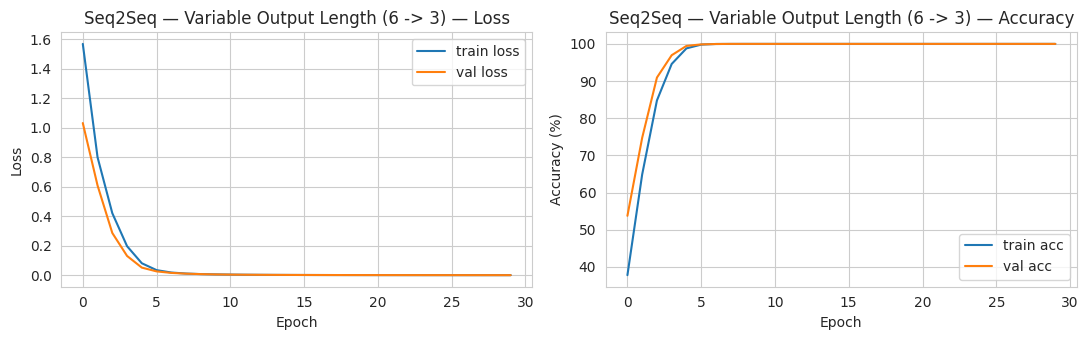

In [45]:
es2 = callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
seq2seq_v2_hist = seq2seq_v2.fit(
    [Xv2_tr, Yv2_tr_in], Yv2_tr,
    validation_data=([Xv2_va, Yv2_va_in], Yv2_va),
    epochs=30, batch_size=64, callbacks=[es2], verbose=0,
)
plot_history(seq2seq_v2_hist, "Seq2Seq — Variable Output Length (6 -> 3)")

In [51]:
encoder2_model = models.Model(enc2_inputs, encoder2_states)

dec2_state_h_in = layers.Input(shape=(LATENT_DIM,))
dec2_state_c_in = layers.Input(shape=(LATENT_DIM,))
dec2_single_input = layers.Input(shape=(1,))
dec2_single_emb = dec2_emb_layer(dec2_single_input)
dec2_single_out, dec2_h, dec2_c = dec2_lstm(dec2_single_emb, initial_state=[dec2_state_h_in, dec2_state_c_in])
dec2_single_out = dec2_dense(dec2_single_out)
decoder2_model = models.Model(
    [dec2_single_input, dec2_state_h_in, dec2_state_c_in],
    [dec2_single_out, dec2_h, dec2_c],
)

def predict_variable_sequence(input_seq, out_len=OUT_LEN):
    states = encoder2_model.predict(input_seq[None, :], verbose=0)
    target = np.array([[START_TOKEN]])
    output = []
    for _ in range(out_len):
        probs, h, c = decoder2_model.predict([target, states[0], states[1]], verbose=0)
        token = int(np.argmax(probs[0, -1, :]))
        output.append(token)
        target = np.array([[token]])
        states = [h, c]
    return np.array(output)

correct_tok2, total_tok2, correct_seq2 = 0, 0, 0
sample_rows2 = []
for i in range(len(Xv2_te)):
    pred = predict_variable_sequence(Xv2_te[i])
    correct_tok2 += (pred == Yv2_te[i]).sum()
    total_tok2 += OUT_LEN
    if np.array_equal(pred, Yv2_te[i]):
        correct_seq2 += 1
    if i < 5:
        sample_rows2.append((Xv2_te[i].tolist(), pred.tolist(), Yv2_te[i].tolist()))

print(f"Token accuracy    : {correct_tok2/total_tok2:.4f}")
print(f"Sequence accuracy : {correct_seq2/len(Xv2_te):.4f}")
print(f"\nInput (len {IN_LEN}) -> Predicted (len {OUT_LEN}) | Target")
for inp, pred, tgt in sample_rows2:
    print(f"{inp} -> {pred}  | {tgt}")

Token accuracy    : 1.0000
Sequence accuracy : 1.0000

Input (len 6) -> Predicted (len 3) | Target
[1, 5, 5, 1, 5, 7] -> [5, 5, 1]  | [5, 5, 1]
[7, 8, 3, 5, 1, 7] -> [3, 8, 7]  | [3, 8, 7]
[4, 1, 2, 2, 3, 2] -> [2, 1, 4]  | [2, 1, 4]
[8, 7, 9, 2, 6, 5] -> [9, 7, 8]  | [9, 7, 8]
[9, 3, 8, 2, 4, 7] -> [8, 3, 9]  | [8, 3, 9]
